# Feature Extraction

This notebook serves to experiment and produce feature extraction methods. I expect the final methods will be implemented in python script files but in the meantime this notebook is a good space for trialing different methods.

In [3]:
import pandas as pd
import pretty_midi
import numpy as np
from tqdm import tqdm
from pathlib import Path

import matplotlib.pyplot as plt

## Load Metadata

In [4]:
metadata_df = pd.read_csv("data/metadata_index.csv")

In [5]:
metadata_df.head()

,track_id,artist_name,artist_id,title,song_id,release,genre,midi_path
0,TRAAAGR128F425B14B,Cyndi Lauper,ARGE7G11187FB37E05,Into The Nightlife,SONRWUU12AF72A4283,Bring Ya To The Brink,NaN,data\midi_files\A\A\A\TRAAAGR128F425B14B
1,TRAAAZF12903CCCF6B,Matthew Wilder,ARJJ8611187FB5321F,Break My Stride,SOUCVHW12AB018E830,I Don't Speak The Language,NaN,data\midi_files\A\A\A\TRAAAZF12903CCCF6B
2,TRAABVM128F92CA9DC,Tesla,ARYKCQI1187FB3B18F,Caught In A Dream,SOXLBJT12A8C140925,Gold,NaN,data\midi_files\A\A\B\TRAABVM128F92CA9DC
3,TRAABXH128F42955D6,Brian Wilson,ARD9UVF1187B9B17FE,Keep An Eye On Summer (Album Version),SOHXFBA12A8C13D637,Imagination,NaN,data\midi_files\A\A\B\TRAABXH128F42955D6
4,TRAACQE12903CC706C,Old Man River,ARDDIBO1187B9B0822,Summer,SOGUCAN12AB017BF99,Good Morning,NaN,data\midi_files\A\A\C\TRAACQE12903CC706C


## Define Helper Functions

In [35]:
def perform_extraction(metadata_df: pd.DataFrame, extraction_func: callable, limit: int = 10) -> pd.DataFrame:

    """Extract features using the provided function for MIDI files listed in the metadata DataFrame. 
    Args:
        metadata_df (pd.DataFrame): DataFrame containing metadata about the MIDI files, including paths.
        extraction_func (callable): Function that takes a MIDI file path and returns a dictionary of extracted features.
        limit (int, optional): Maximum number of rows to process for testing. Defaults to 10."""

    rows = []

    for idx, row in tqdm(metadata_df.iterrows(), total=metadata_df.shape[0]):

        if idx < limit:  # Process only the first `limit` rows for testing
            features = extraction_func(row["midi_path"])
        
            if features is not None:
                features["track_id"] = row["track_id"]
                features["artist"] = row["artist_name"]
                features["title"] = row["title"]
                rows.append(features)

    return pd.DataFrame(rows)

In [ ]:
def plot_histogram(dataframe, include_cols=None, exclude_cols=None, n=3):

    """Plot histograms for specified columns in the DataFrame.
    Assumes that the columns contain list-like data (e.g., histograms or distributions) that can be plotted as bar charts.
    You can include or exclude specific columns by name using the `include_cols` and `exclude_cols` parameters.
    The `n` parameter limits the number of songs plotted for clarity."""
    
    for col in dataframe.columns:
            if include_cols and col not in include_cols:
                continue
            if exclude_cols and col in exclude_cols:
                continue

            plt.figure(figsize=(12, 5))

            x = None

            for i, row in enumerate(dataframe.itertuples()):
                if i >= n:  # limit to first n songs for clarity
                    break
                values = np.array(getattr(row, col))

                if x is None:
                    x = np.arange(len(values))

                plt.bar(
                    x + i * 0.2,   # small offset so bars don't overlap
                    values,
                    width=0.2,
                    alpha=0.6,
                    label=row.title
                )

            plt.title(f"{col} comparison across songs")
            plt.xlabel("Bin")
            plt.ylabel("Frequency")
            plt.legend()
            plt.show()

## Initial Extraction

The idea here is to test the folder architecture and see how features can be extracted with the pretty_midi library.

In [6]:
def extract_init_features(midi_path):
    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid"))

    if len(midi_files) == 0: # if folder empty return none
        return None

    
    pitches, durations, velocities = [], [], []
    instruments_count = []

    for file in midi_files:
        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        instruments_count.append(len(midi.instruments))

        for instrument in midi.instruments:
            for note in instrument.notes:
                pitches.append(note.pitch)
                durations.append(note.end - note.start)
                velocities.append(note.velocity)

    if len(pitches) == 0:
        return None

    return {
        "mean_pitch": np.mean(pitches),
        "std_pitch": np.std(pitches),
        "pitch_range": max(pitches) - min(pitches),

        "mean_duration": np.mean(durations),
        "std_duration": np.std(durations),

        "mean_velocity": np.mean(velocities),
        "std_velocity": np.std(velocities),

        "note_count": len(pitches),

        "num_files": len(midi_files),
        "mean_instruments": np.mean(instruments_count),

        "path": str(midi_path)
    }

Since extracting features from the whole dataset is time consuming, for now extraction will be limited for just the first 10 tracks. Also, to mak eit easier to test different extractor functions, an auxiliary function is designed.

In [7]:
def perform_extraction(metadata_df: pd.DataFrame, extraction_func: callable, limit: int = 10) -> pd.DataFrame:
    """Extract features for all MIDI files listed in the metadata DataFrame. Optionally limit the number of rows processed for testing purposes."""

    rows = []

    for idx, row in tqdm(metadata_df.iterrows(), total=metadata_df.shape[0]):

        if idx < limit:  # Process only the first `limit` rows for testing
            features = extraction_func(row["midi_path"])
        
            if features is not None:
                features["track_id"] = row["track_id"]
                features["artist"] = row["artist_name"]
                features["title"] = row["title"]
                rows.append(features)

    return pd.DataFrame(rows)

With this setup, the initial extractor function is tested.

In [8]:
features_df = perform_extraction(metadata_df, extraction_func=extract_init_features, limit=10)
features_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:06<00:00, 4886.02it/s] 


,mean_pitch,std_pitch,pitch_range,mean_duration,std_duration,mean_velocity,std_velocity,note_count,num_files,mean_instruments,path,track_id,artist,title
0,56.463621,14.739858,69,0.219450,0.332052,85.760812,26.087870,30361,4,13.750000,data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,59.089824,13.039503,65,0.135897,0.191376,103.824553,14.018395,30237,6,10.000000,data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,54.702350,12.121203,72,0.617495,1.075504,82.003550,28.893779,20000,5,11.000000,data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,59.063735,12.701481,74,0.515477,0.702577,87.410415,25.462782,21354,5,9.600000,data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,52.184508,11.216490,62,0.407937,0.579876,83.311443,25.024830,18151,3,12.666667,data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


As a fist proof of working enviornment, this table is useful. Beyond this however, my intuition on these features being useful ways to measure song simmilarity is questionable. Global aggregation across a track to a mean or other descriptive statistic probably does not capture the differences which make songs sound dis/simmilar.

Instead of looking at mean picth, below I look at extracting pitch distributions. This can serve to represent song structure better.

In [9]:
def extract_pitch_distributions(midi_path):
    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid")) + list(midi_path.glob("*.midi"))

    if len(midi_files) == 0:
        return None

    pitches = []

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            for note in instrument.notes:
                pitches.append(note.pitch)

    if len(pitches) == 0:
        return None

    return {
        "pitch_hist": np.histogram(pitches, bins=128, range=(0, 127))[0],
        "path": str(midi_path)
    }

In [10]:
pitch_distributions_df = perform_extraction(metadata_df, extraction_func=extract_pitch_distributions, limit=10)
pitch_distributions_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:05<00:00, 5298.92it/s] 


,pitch_hist,path,track_id,artist,title
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


In [11]:
for row in pitch_distributions_df.itertuples():
    print(f"Track ID: {row.track_id}, Pitch Distribution: {row.pitch_hist}")

Track ID: TRAAAGR128F425B14B, Pitch Distribution: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0   76    0
  310  339    0  385    0  450    0 1050  685    0  753  388   63  292
 1924  384 1864  288  857   36  327   27  505    0  226 1090  752 1394
    0 1712    0  467 1975  384  694    0  895  574    0  876    0 1103
 1564  458 1392    0  531  616  519  140    0  499    0  408   80  116
  300    0  115    0  138    0    0   20    0  318    0    2    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]
Track ID: TRAAAZF12903CCCF6B, Pitch Distribution: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    2   26
    0   80   27  183    0  241  200  132 1475    0  583  517  980  268
 1859  113    0   77  220   21   52 

Simmilar distribution histograms can be obtained for the other descriptive features first extracted. Further, these can be done in the way above where an absoloute count is captured, but also as a distribution percentage allowing for other kinds of comparison when the number of pitches is significantly different between tracks. This is done below:

In [12]:
def extract_feature_histograms(midi_path):
    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid"))

    if len(midi_files) == 0: # if folder empty return none
        return None

    
    pitches, durations, velocities = [], [], []

    for file in midi_files:
        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            for note in instrument.notes:
                pitches.append(note.pitch)
                durations.append(note.end - note.start)
                velocities.append(note.velocity)

    if len(pitches) == 0:
        return None

    return {
        "pitch_hist": np.histogram(pitches, bins=128, range=(0, 127))[0],
        "pitch_hist_norm": np.histogram(pitches, bins=128, range=(0, 127))[0] / len(pitches),

        "duration_hist": np.histogram(durations, bins=128)[0],
        "duration_hist_norm": np.histogram(durations, bins=128)[0] / len(durations),

        "velocity_hist": np.histogram(velocities, bins=128)[0],
        "velocity_hist_norm": np.histogram(velocities, bins=128)[0] / len(velocities),

        "path": str(midi_path)
    }

In [13]:
feature_distributions_df = perform_extraction(metadata_df, extraction_func=extract_feature_histograms, limit=10)
feature_distributions_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:05<00:00, 5291.49it/s] 


,pitch_hist,pitch_hist_norm,duration_hist,duration_hist_norm,velocity_hist,velocity_hist_norm,path,track_id,artist,title
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[7835, 5398, 2787, 2213, 1699, 726, 4508, 427,...","[0.25806132867823856, 0.17779388030697277, 0.0...","[221, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[0.007279075129277692, 0.0, 0.0, 0.0, 0.0, 0.0...",data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1170, 12826, 6108, 2853, 2190, 592, 1125, 391...","[0.03869431491219367, 0.4241822932169197, 0.20...","[4, 0, 0, 4, 4, 0, 4, 0, 4, 4, 0, 4, 0, 0, 0, ...","[0.00013228825611006384, 0.0, 0.0, 0.000132288...",data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[8520, 2645, 2127, 927, 453, 2104, 79, 326, 19...","[0.426, 0.13225, 0.10635, 0.04635, 0.02265, 0....","[68, 1, 1, 9, 2, 4, 5, 7, 7, 12, 5, 1, 10, 10,...","[0.0034, 5e-05, 5e-05, 0.00045, 0.0001, 0.0002...",data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3990, 2407, 1584, 3608, 1163, 906, 410, 1755,...","[0.18685023883113233, 0.11271892853797884, 0.0...","[114, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0...","[0.005338578252318067, 0.0, 0.0, 0.0, 9.365926...",data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4219, 2173, 2374, 3025, 726, 607, 552, 330, 1...","[0.23243898407801222, 0.1197179218775825, 0.13...","[1, 0, 1, 0, 0, 0, 0, 0, 0, 4, 0, 2, 28, 29, 2...","[5.509338328466751e-05, 0.0, 5.509338328466751...",data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


In [14]:
feature_distributions_df.dtypes

pitch_hist            object
pitch_hist_norm       object
duration_hist         object
duration_hist_norm    object
velocity_hist         object
velocity_hist_norm    object
path                     str
track_id                 str
artist                   str
title                    str
dtype: object

With this, some plots can be produced to see if these features give some viable discerning value.

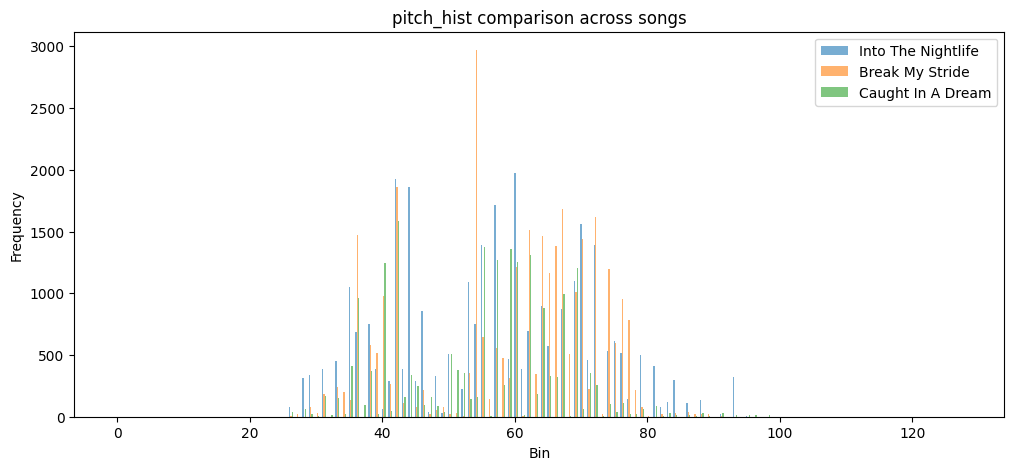

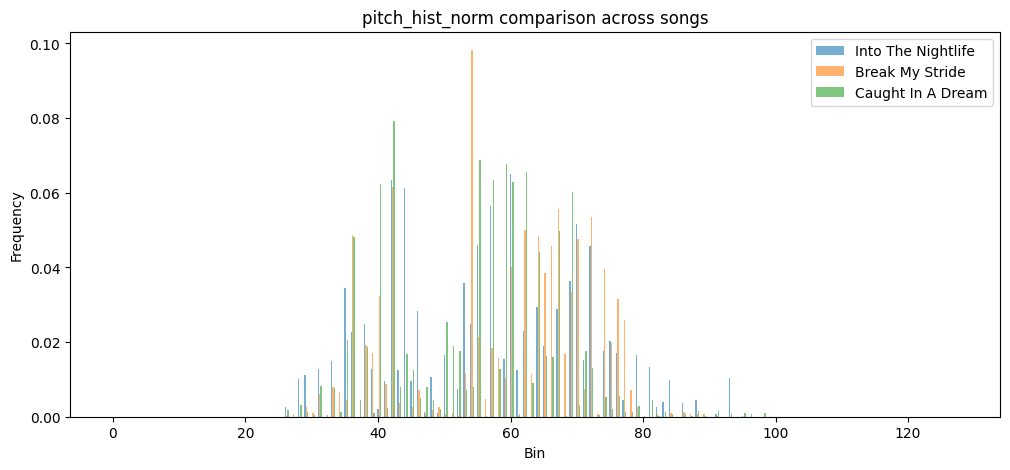

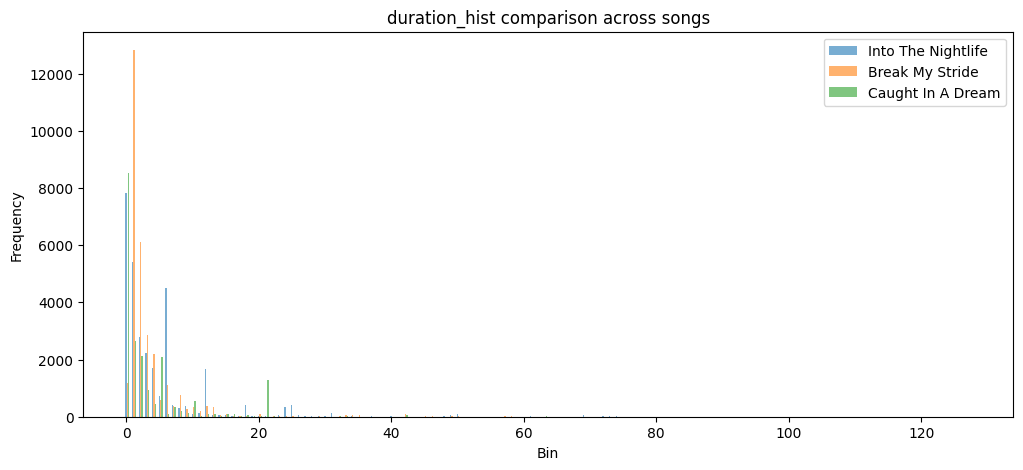

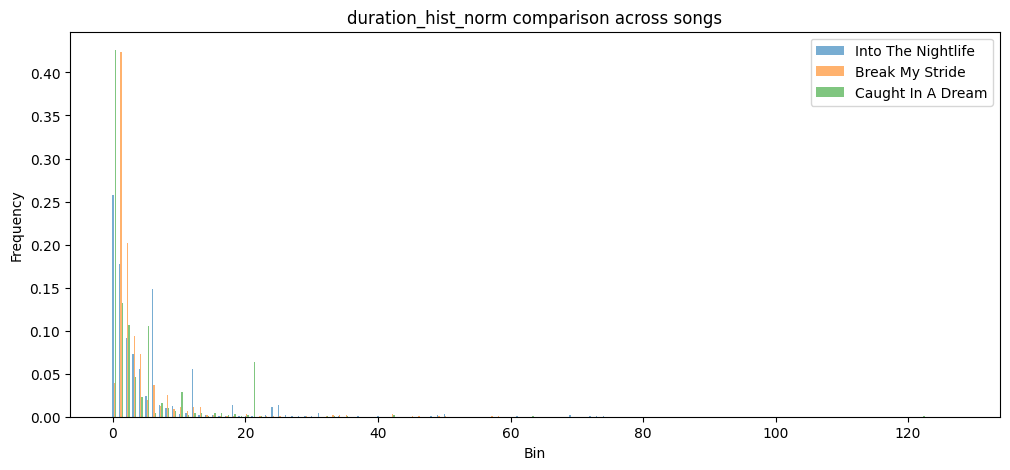

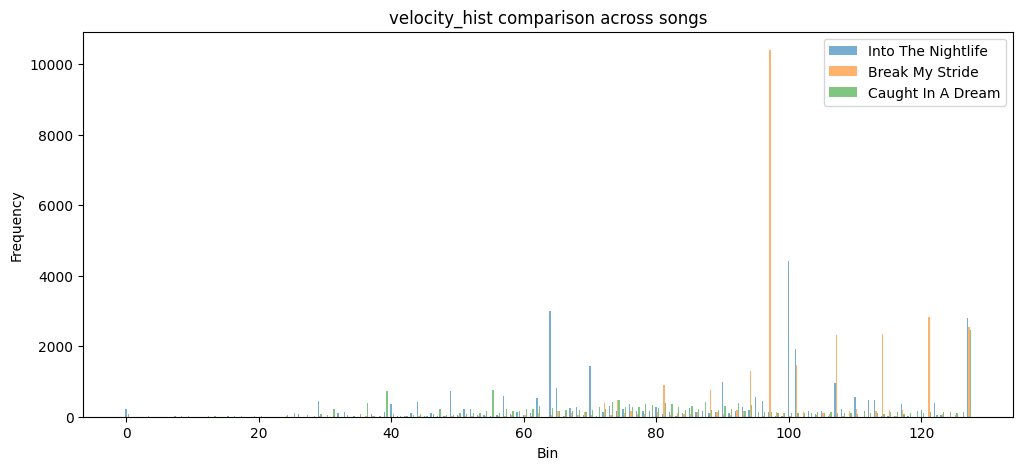

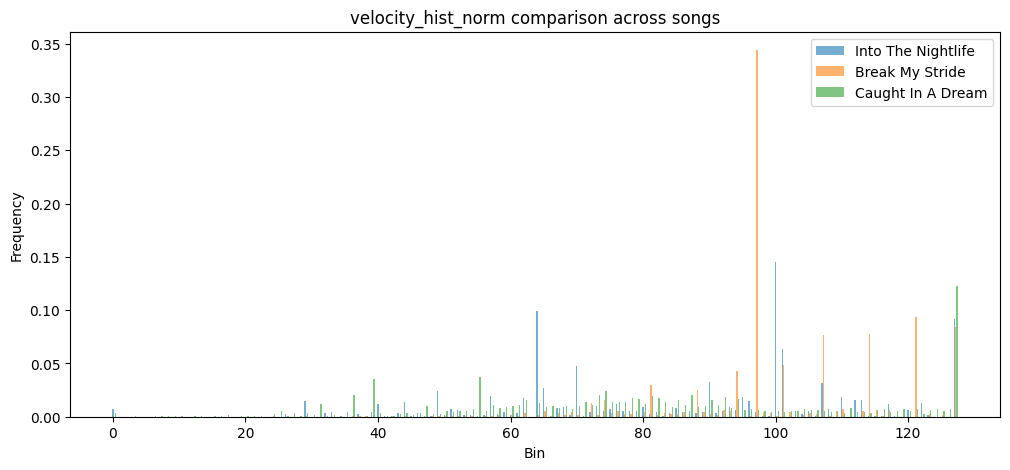

In [41]:
plot_histogram(feature_distributions_df, exclude_cols=["path", "track_id", "artist", "title"], n=3)

The efficacy of these features for measuring song simmilarity is not obvious from these plots, though it can be seen that the songs do have different spikes. Perhaps taken over a larger sample, with aggregation for genre more obvious clusters emerge.

For songs with simillar motifs, these may be more obvious or recognisable from pitch classes. There are 12 distinct pitches in an octave and so with some modular arithmetic these could be captured. (PERHAPS EXPLAIN MORE? MAYBE ELSEWHERE? DEDICATED MUSIC THEORY LIT REVIEW/RESEARCH DOC?)

In [16]:
def extract_chroma_features(midi_path, use_velocity=True):

    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid"))

    if len(midi_files) == 0: # if folder empty return none
        return None

    for file in midi_files:
        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

    chroma_counts = np.zeros(12)
    chroma_weighted = np.zeros(12)

    for instrument in midi.instruments:
        if instrument.is_drum:
            continue

        for note in instrument.notes:
            pc = note.pitch % 12


            weight = note.end - note.start  # duration weighting
            weight *= note.velocity / 127.0

            chroma_counts[pc] += 1
            chroma_weighted[pc] += weight

    chroma_counts = chroma_counts / (chroma_counts.sum() + 1e-9)
    chroma_weighted = chroma_weighted / (chroma_weighted.sum() + 1e-9)

    return {
        "chroma": chroma_counts,
        "chroma_weighted": chroma_weighted,
        "path": str(midi_path)
    }

In [17]:
chroma_features_df = perform_extraction(metadata_df, extraction_func=extract_chroma_features, limit=10)
chroma_features_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:06<00:00, 5118.42it/s] 


,chroma,chroma_weighted,path,track_id,artist,title
0,"[0.26969453376200364, 0.0, 0.1081189710610715,...","[0.3210009957593557, 0.0, 0.08652591658619381,...",data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0.16139425893375473, 0.0014645577035730917, 0...","[0.14805535071675355, 0.000289164782823572, 0....",data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0.135488557936747, 0.0, 0.16745368688697151, ...","[0.12587992968821446, 0.0, 0.19802343140887116...",data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0.14930325149298299, 0.0006635700066354799, 0...","[0.17188303497182922, 0.004721675020710948, 0....",data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0.0016977928692695887, 0.03692699490661355, 0...","[0.0023041344059208523, 0.0376561977603724, 0....",data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


In [18]:
chroma_features_df.dtypes

chroma             object
chroma_weighted    object
path                  str
track_id              str
artist                str
title                 str
dtype: object

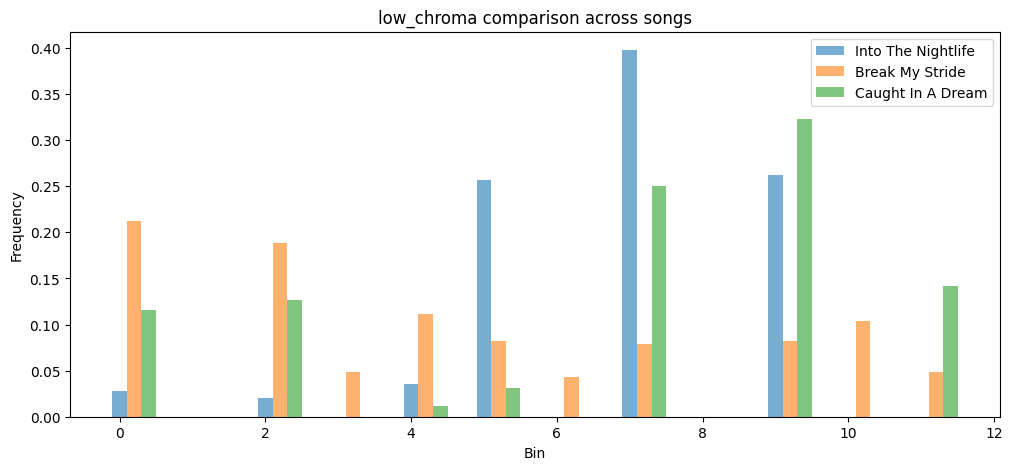

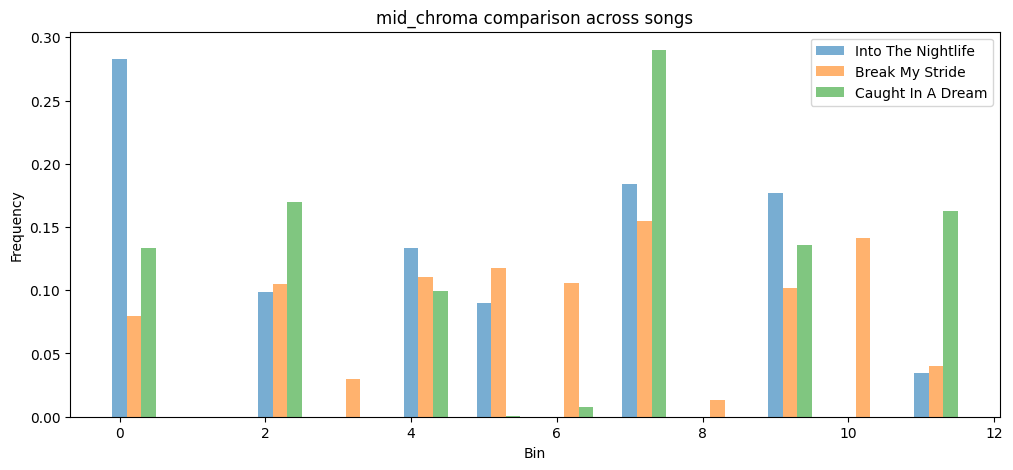

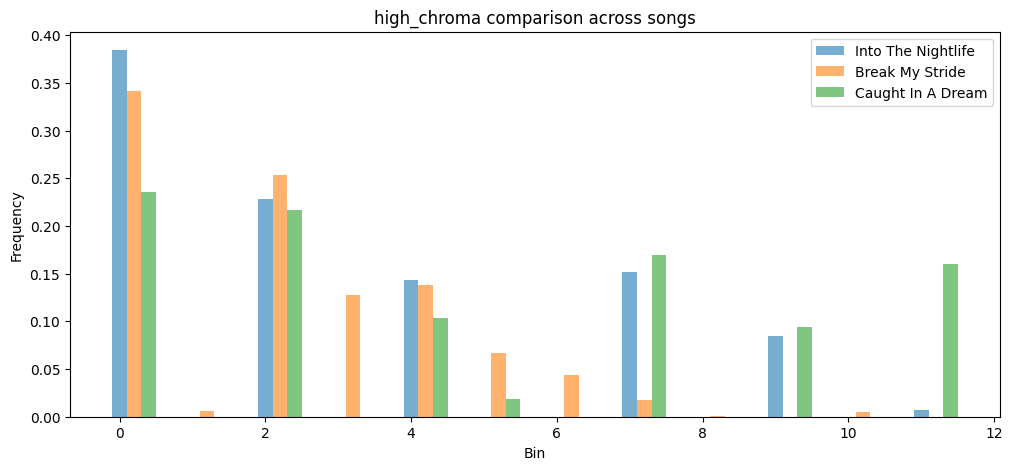

In [39]:
plot_histogram(register_chroma_df, include_cols=["low_chroma", "mid_chroma", "high_chroma"], n=3)

Here differences in song structure become more apparent and the usefulness of the feature seems more obvious, though again, this is only from intuition. Proper feature importance should be discerned later. 

Also, because all pitches are being mapped into 12 bins, bass and melody are mixed. To better capture structure, a filetr could be used to capture low, middle and high notes and then map to three diferrent chroma features.

The order of notes, rhythm, key, chords and mode are also still uncaptured.

In [20]:
LOW_MAX = 47    # B2 (0 to 47 are considered low)
MID_MAX = 71    # B4 (48 to 71 are mid)
                # High is 72 and above (C5 and above)

def extract_register_chroma(midi_path: str)-> dict:

    midi_path = Path(midi_path)

    # all midi files directly inside the folder
    midi_files = list(midi_path.glob("*.mid"))

    if len(midi_files) == 0: # if folder empty return none
        return None

    for file in midi_files:
        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

    low = np.zeros(12)
    mid = np.zeros(12)
    high = np.zeros(12)

    low_weighted = np.zeros(12)
    mid_weighted = np.zeros(12)
    high_weighted = np.zeros(12)

    for instrument in midi.instruments:

        if instrument.is_drum:
            continue

        for note in instrument.notes:

            pc = note.pitch % 12

            duration = note.end - note.start
            velocity = note.velocity / 127

            weight = duration * velocity

            if note.pitch < 48:

                low[pc] += 1
                low_weighted[pc] += weight

            elif note.pitch < 72:

                mid[pc] += 1
                mid_weighted[pc] += weight

            else:

                high[pc] += 1
                high_weighted[pc] += weight

    def normalize(x):
        return x / (x.sum() + 1e-9)

    return {
        "low_chroma": normalize(low),
        "mid_chroma": normalize(mid),
        "high_chroma": normalize(high),

        "low_chroma_weighted": normalize(low_weighted),
        "mid_chroma_weighted": normalize(mid_weighted),
        "high_chroma_weighted": normalize(high_weighted),
        "path": str(midi_path)
    }

In [21]:
register_chroma_df = perform_extraction(metadata_df, extraction_func=extract_register_chroma, limit=10)
register_chroma_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:05<00:00, 5331.92it/s] 


,low_chroma,mid_chroma,high_chroma,low_chroma_weighted,mid_chroma_weighted,high_chroma_weighted,path,track_id,artist,title
0,"[0.027881040892141485, 0.0, 0.0204460966542370...","[0.2830793905372138, 0.0, 0.0983694199411659, ...","[0.3845050215202518, 0.0, 0.22812051649895534,...","[0.02535429836362552, 0.0, 0.00845143278787517...","[0.36154629339171634, 0.0, 0.08101461858279511...","[0.43764668485367475, 0.0, 0.23539508887055088...",data\midi_files\A\A\A\TRAAAGR128F425B14B,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0.21253405994492497, 0.0, 0.18801089918204902...","[0.07972350230411072, 0.0, 0.10506912442391471...","[0.34207525655605237, 0.005701254275934206, 0....","[0.17349176711283346, 0.0, 0.1561596393316235,...","[0.10614982734447452, 0.0, 0.13340832454460416...","[0.24982591684591318, 0.0015566612998984472, 0...",data\midi_files\A\A\A\TRAAAZF12903CCCF6B,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0.11538461538417161, 0.0, 0.12692307692258875...","[0.13322161709252903, 0.0, 0.16966904063671148...","[0.2358490566015486, 0.0, 0.2169811320734247, ...","[0.11342308438328134, 0.0, 0.12899565277882058...","[0.12563970970646182, 0.0, 0.21630656373390741...","[0.18526148251920277, 0.0, 0.18202425441744943...",data\midi_files\A\A\B\TRAABVM128F92CA9DC,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0.21097046413413093, 0.0, 0.23628691983022665...","[0.1845238095236526, 0.0008503401360536987, 0....","[0.11430356027475684, 0.0006246096189877423, 0...","[0.22592396867247236, 0.0, 0.24476799304601016...","[0.15929210627705315, 0.00478747675870006, 0.1...","[0.16496938132390876, 0.007189656045733109, 0....",data\midi_files\A\A\B\TRAABXH128F42955D6,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0.0, 0.0, 0.15589353612152482, 0.0, 0.1207224...","[0.0021984061555366313, 0.04671613080515342, 0...","[0.0, 0.1904761904671202, 0.28571428570068025,...","[0.0, 0.0, 0.17180175282443796, 0.0, 0.1015590...","[0.002917282169145773, 0.04712177123092519, 0....","[0.0, 0.0906331057826105, 0.37552401654098094,...",data\midi_files\A\A\C\TRAACQE12903CC706C,TRAACQE12903CC706C,Old Man River,Summer


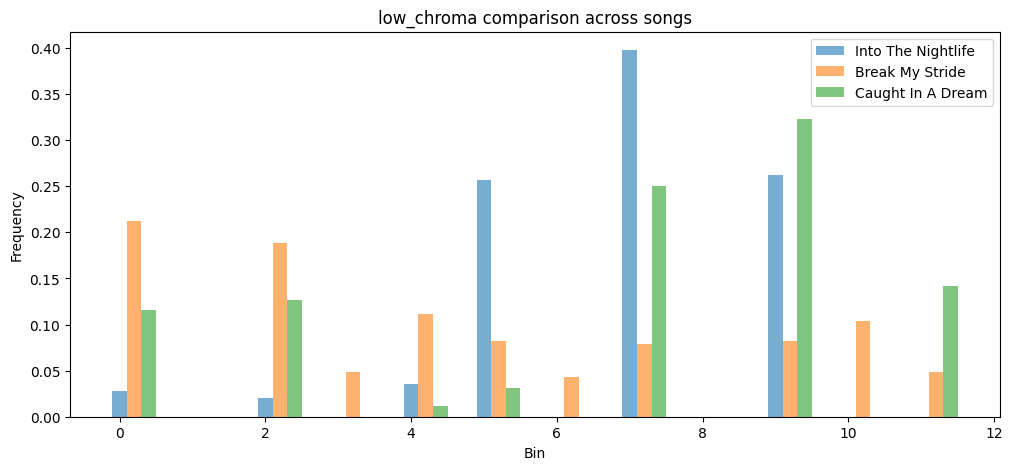

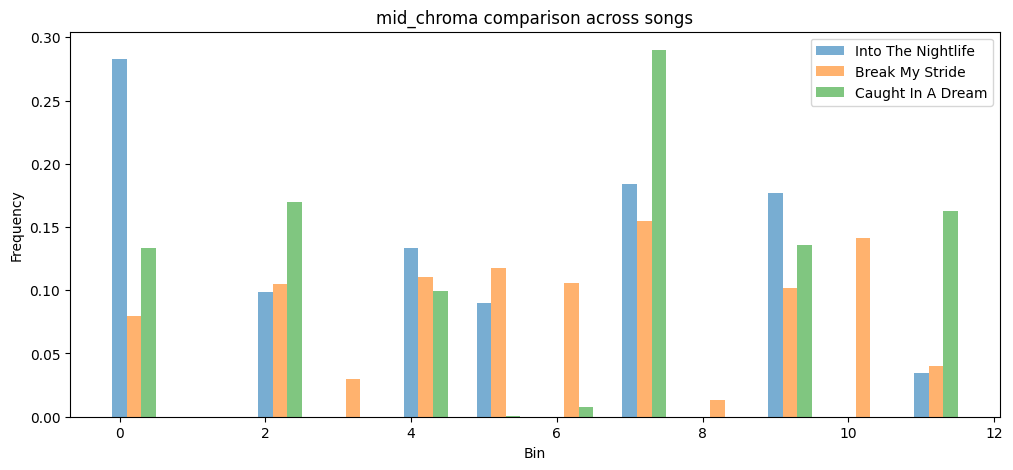

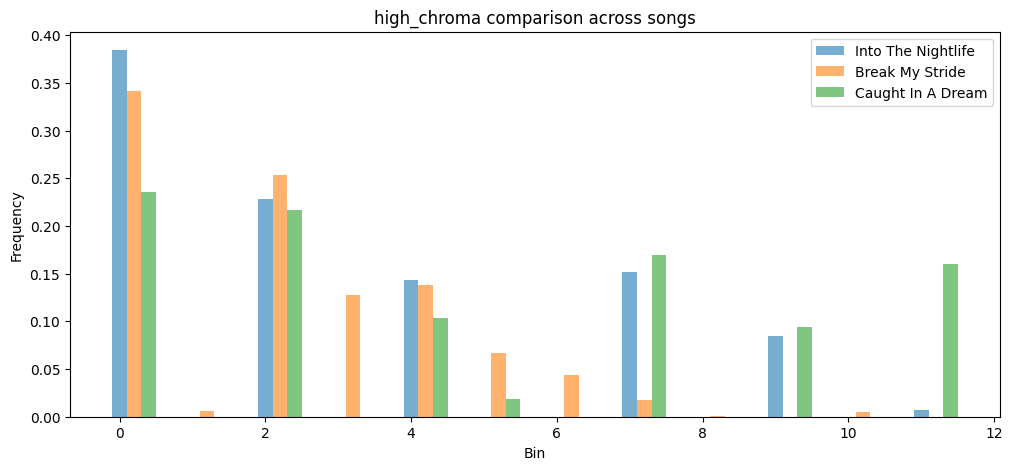

In [38]:
plot_histogram(register_chroma_df, include_cols=["low_chroma", "mid_chroma", "high_chroma"], n=3)

Here it can be seen that (COMMENT ON EFFICACY)

On capturing sequences next:

TODO: 

a) Implement n-gram style sequences next capturing both chroma and transposition so C->G->B and +1->+3->-2 etc...

b) Look at drums and rhythms some more

c) explore instruments? Create a semantic field from instrument names?

c#) ammend plotting scripts to use a re-usable function

d) begin research on how the visual will be put together, where can this be hosted?

In [27]:
def extract_ngrams(midi_path, n=3):

    midi_path = Path(midi_path)

    midi_files = list(midi_path.glob("*.mid"))

    if len(midi_files) == 0:
        return None

    pitches = []

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:

            if instrument.is_drum:
                continue

            for note in instrument.notes:
                pitches.append(note.pitch)

    if len(pitches) < 2:
        intervals = np.array([], dtype=int)
        ngram_counts = Counter()

    else:
        intervals = np.diff(pitches)

        ngrams = [
            tuple(intervals[i:i+n])
            for i in range(len(intervals) - n + 1)
        ]

        ngram_counts = Counter(ngrams)

    return {
        "path": str(midi_path),
        "intervals": intervals,
        "interval_ngrams": ngram_counts
    }

In [28]:
ngrams_df = perform_extraction(metadata_df, extraction_func=extract_ngrams, limit=10)
ngrams_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:07<00:00, 4414.97it/s] 


,path,intervals,interval_ngrams,track_id,artist,title
0,data\midi_files\A\A\A\TRAAAGR128F425B14B,"[7, -2, -2, -3, 7, -2, -2, 2, -2, -7, 7, -1, -...","{(7, -2, -2): 80, (-2, -2, -3): 54, (-2, -3, 7...",TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,data\midi_files\A\A\A\TRAAAZF12903CCCF6B,"[9, -2, -4, 9, -15, 12, -2, -4, 9, -3, -2, -4,...","{(9, -2, -4): 24, (-2, -4, 9): 304, (-4, 9, -1...",TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,data\midi_files\A\A\B\TRAABVM128F92CA9DC,"[3, 0, 2, 1, 1, -2, -2, -3, 3, 2, 2, -2, -2, -...","{(3, 0, 2): 2, (0, 2, 1): 2, (2, 1, 1): 3, (1,...",TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,data\midi_files\A\A\B\TRAABXH128F42955D6,"[4, 1, 0, -1, 1, 2, -2, -5, 0, 4, 1, 2, -2, -5...","{(4, 1, 0): 7, (1, 0, -1): 5, (0, -1, 1): 2, (...",TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,data\midi_files\A\A\C\TRAACQE12903CC706C,"[0, -3, 0, 1, 0, 0, 2, 0, -3, 0, 1, 0, 0, -10,...","{(0, -3, 0): 12, (-3, 0, 1): 4, (0, 1, 0): 52,...",TRAACQE12903CC706C,Old Man River,Summer


In [26]:
ngrams_df.shape

(10, 6)

TALK ABOUT EXTENSION TO picth classes and capturing melody.

In [29]:
from collections import Counter, defaultdict


def make_ngrams(sequence, n=3):
    return [
        tuple(sequence[i:i+n])
        for i in range(len(sequence) - n + 1)
    ]


def interval_ngrams(notes, n=3):

    if len(notes) < 2:
        return np.array([], dtype=int), Counter()

    notes.sort(key=lambda x: x[0])

    pitches = np.array([pitch for _, pitch in notes])

    intervals = np.diff(pitches)

    # clip large jumps
    intervals = np.clip(intervals, -12, 12)

    ngrams = make_ngrams(intervals, n)

    return intervals, Counter(ngrams)


def extract_complete_ngrams(midi_path, n=3):

    midi_path = Path(midi_path)

    midi_files = list(midi_path.glob("*.mid"))

    if not midi_files:
        return None

    all_notes = []

    low_notes = []
    mid_notes = []
    high_notes = []

    LOW_MAX = 48
    MID_MAX = 72

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:

            if instrument.is_drum:
                continue

            for note in instrument.notes:

                event = (note.start, note.pitch)

                all_notes.append(event)

                if note.pitch < LOW_MAX:
                    low_notes.append(event)

                elif note.pitch < MID_MAX:
                    mid_notes.append(event)

                else:
                    high_notes.append(event)

    # -------------------------
    # Melody extraction
    # -------------------------

    by_time = defaultdict(list)

    for start, pitch in all_notes:
        by_time[start].append(pitch)

    melody_notes = [
        (start, max(pitches))
        for start, pitches in by_time.items()
    ]

    # -------------------------
    # Interval + n-grams
    # -------------------------

    melody_intervals, melody_ngrams = interval_ngrams(
        melody_notes, n
    )

    low_intervals, low_ngrams = interval_ngrams(
        low_notes, n
    )

    mid_intervals, mid_ngrams = interval_ngrams(
        mid_notes, n
    )

    high_intervals, high_ngrams = interval_ngrams(
        high_notes, n
    )

    return {

        "path": str(midi_path),

        "melody_intervals": melody_intervals,
        "melody_ngrams": melody_ngrams,

        "low_intervals": low_intervals,
        "low_ngrams": low_ngrams,

        "mid_intervals": mid_intervals,
        "mid_ngrams": mid_ngrams,

        "high_intervals": high_intervals,
        "high_ngrams": high_ngrams,
    }

In [30]:
ngrams_df = perform_extraction(metadata_df, extraction_func=extract_complete_ngrams, limit=10)
ngrams_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:08<00:00, 3614.46it/s] 


,path,melody_intervals,melody_ngrams,low_intervals,low_ngrams,mid_intervals,mid_ngrams,high_intervals,high_ngrams,track_id,artist,title
0,data\midi_files\A\A\A\TRAAAGR128F425B14B,"[7, -5, 12, 0, -12, 10, -2, -8, 10, -5, 3, 4, ...","{(7, -5, 12): 3, (-5, 12, 0): 4, (12, 0, -12):...","[12, -12, 12, -12, 12, -12, 12, -12, 12, -12, ...","{(12, -12, 12): 30, (-12, 12, -12): 34, (-12, ...","[3, 5, 2, 7, -5, 0, 0, -12, 8, -5, 12, -5, -4,...","{(3, 5, 2): 9, (5, 2, 7): 4, (2, 7, -5): 2, (7...","[0, -2, -2, 2, -2, 4, -2, 2, -4, 2, 0, -2, 0, ...","{(0, -2, -2): 2, (-2, -2, 2): 13, (-2, 2, -2):...",TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,data\midi_files\A\A\A\TRAAAZF12903CCCF6B,"[-12, 12, 0, -3, -12, -12, 12, 0, -3, 3, -3, -...","{(-12, 12, 0): 48, (12, 0, -3): 17, (0, -3, -1...","[0, 0, 0, -3, 0, 0, 0, 3, 0, -3, 10, 0, -12, 0...","{(0, 0, 0): 469, (0, 0, -3): 31, (0, -3, 0): 2...","[0, 0, 0, 7, -4, 4, 0, -4, 4, 0, -4, 4, 0, -4,...","{(0, 0, 0): 1545, (0, 0, 7): 43, (0, 7, -4): 1...","[0, 0, 0, 0, -3, 3, -3, 3, -3, 3, -3, 0, 0, 0,...","{(0, 0, 0): 1078, (0, 0, -3): 68, (0, -3, 3): ...",TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,data\midi_files\A\A\B\TRAABVM128F92CA9DC,"[-9, 9, -12, 3, 5, 4, 12, 3, -12, 12, 3, -7, -...","{(-9, 9, -12): 3, (9, -12, 3): 2, (-12, 3, 5):...","[12, -12, 12, -12, 7, 9, -7, -12, 5, 12, -2, 0...","{(12, -12, 12): 39, (-12, 12, -12): 15, (12, -...","[4, -9, 0, 5, -5, 5, 4, -9, 5, -5, 5, 4, 12, -...","{(4, -9, 0): 70, (-9, 0, 5): 64, (0, 5, -5): 5...","[0, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, -2...","{(0, -2, 0): 5, (-2, 0, 0): 8, (0, 0, 0): 91, ...",TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,data\midi_files\A\A\B\TRAABXH128F42955D6,"[-12, 3, -2, 11, 3, -3, -3, 6, -3, -4, 7, -3, ...","{(-12, 3, -2): 1, (3, -2, 11): 1, (-2, 11, 3):...","[0, 7, 2, 0, -5, 0, -12, 12, -12, 10, 7, -2, 0...","{(0, 7, 2): 3, (7, 2, 0): 1, (2, 0, -5): 2, (0...","[-3, -12, 12, 4, -4, -5, -3, 3, 5, 4, -9, 5, 4...","{(-3, -12, 12): 36, (-12, 12, 4): 9, (12, 4, -...","[-3, -4, 4, -4, 7, -3, -4, 1, 3, -4, 7, -3, -4...","{(-3, -4, 4): 26, (-4, 4, -4): 20, (4, -4, 7):...",TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,data\midi_files\A\A\C\TRAACQE12903CC706C,"[0, -12, 4, 5, 0, -12, 12, 2, -2, -5, -7, 12, ...","{(0, -12, 4): 1, (-12, 4, 5): 1, (4, 5, 0): 1,...","[0, -3, 0, 1, 0, 2, -2, 2, -3, 0, 1, 0, 2, 0, ...","{(0, -3, 0): 2, (-3, 0, 1): 3, (0, 1, 0): 5, (...","[-5, 0, -7, 12, -5, 0, -7, -3, 7, 0, 5, -5, 5,...","{(-5, 0, -7): 18, (0, -7, 12): 26, (-7, 12, -5...","[0, 0, 0, -3, 1, 0, 5, -5, 4, -2, -3, 1, 5, -5...","{(0, 0, 0): 34, (0, 0, -3): 1, (0, -3, 1): 1, ...",TRAACQE12903CC706C,Old Man River,Summer


## Rhythm

With pitch and sequence covered, I will now look at rhythm.

In [31]:
from pathlib import Path
import numpy as np
import pretty_midi


def extract_rhythm_features(midi_path, n_ioi_bins=10, n_dur_bins=10):

    midi_path = Path(midi_path)

    midi_files = list(midi_path.glob("*.mid"))
    if not midi_files:
        return None

    all_notes = []

    # -------------------------
    # Collect note events
    # -------------------------
    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            if instrument.is_drum:
                continue

            for note in instrument.notes:
                all_notes.append((note.start, note.end))

    if len(all_notes) < 2:
        return {
            "ioi_hist": np.zeros(n_ioi_bins),
            "duration_hist": np.zeros(n_dur_bins),
            "density": 0.0,
            "polyphony_mean": 0.0,
            "polyphony_max": 0.0
        }

    # -------------------------
    # Sort by time
    # -------------------------
    all_notes.sort(key=lambda x: x[0])

    starts = np.array([n[0] for n in all_notes])
    ends = np.array([n[1] for n in all_notes])

    # -------------------------
    # IOI (Inter-Onset Intervals)
    # -------------------------
    iois = np.diff(starts)
    iois = iois[iois > 0]

    if len(iois) == 0:
        ioi_hist = np.zeros(n_ioi_bins)
    else:
        ioi_hist = np.histogram(
            iois,
            bins=np.logspace(-3, 1, n_ioi_bins + 1)
        )[0]
        ioi_hist = ioi_hist / (ioi_hist.sum() + 1e-9)

    # -------------------------
    # Durations
    # -------------------------
    durations = ends - starts

    duration_hist = np.histogram(
        durations,
        bins=np.logspace(-3, 1, n_dur_bins + 1)
    )[0]
    duration_hist = duration_hist / (duration_hist.sum() + 1e-9)

    # -------------------------
    # Density
    # -------------------------
    total_time = max(ends) - min(starts) + 1e-9
    density = len(all_notes) / total_time

    # -------------------------
    # Polyphony (approximation)
    # -------------------------
    time_grid = np.linspace(min(starts), max(ends), 200)

    polyphony = np.array([
        np.sum((starts <= t) & (ends >= t))
        for t in time_grid
    ])

    polyphony_mean = float(polyphony.mean())
    polyphony_max = float(polyphony.max())

    # -------------------------
    # Return feature dict
    # -------------------------
    return {
        "ioi_hist": ioi_hist,
        "duration_hist": duration_hist,
        "density": density,
        "polyphony_mean": polyphony_mean,
        "polyphony_max": polyphony_max
    }

In [32]:
rhythm_features_df = perform_extraction(metadata_df, extraction_func=extract_rhythm_features, limit=10)
rhythm_features_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:09<00:00, 3253.94it/s] 


,ioi_hist,duration_hist,density,polyphony_mean,polyphony_max,track_id,artist,title
0,"[0.08676319689886139, 0.21913122791013348, 0.2...","[0.0, 0.0, 0.0, 0.034234995773455505, 0.246618...",66.883392,20.67,43.0,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0.02141176470587731, 0.37199999999991246, 0.1...","[0.0, 0.006039399894549871, 0.0162967933662456...",112.121283,18.01,55.0,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0.008471645919777235, 0.30411479944669706, 0....","[0.0, 0.00014159292035397227, 0.00184070796460...",42.982120,35.75,60.0,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0.015563472717041896, 0.15844740296265544, 0....","[0.0, 0.00017897625581671762, 0.01324424293043...",64.135186,40.44,69.0,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0.01592356687897628, 0.3954834973942109, 0.10...","[0.0, 0.0, 0.00016181229773461474, 0.011165048...",53.808577,30.15,55.0,TRAACQE12903CC706C,Old Man River,Summer


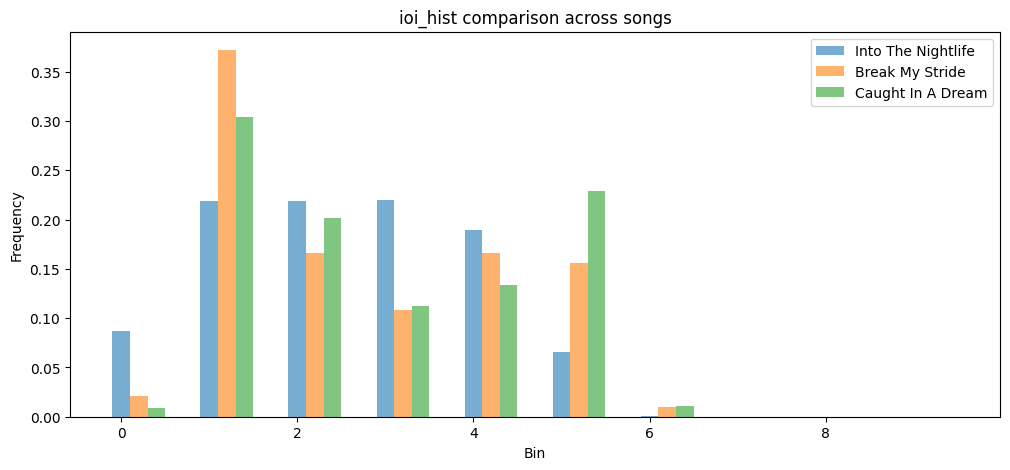

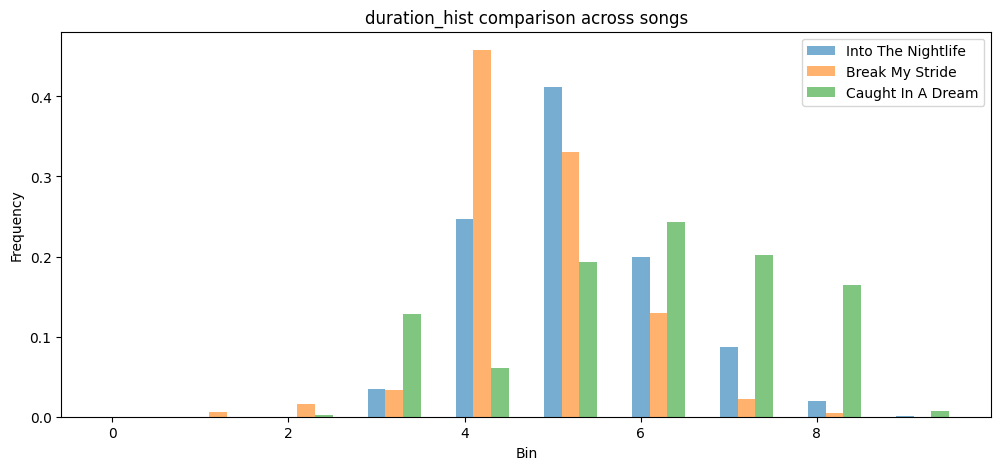

In [37]:
plot_histogram(rhythm_features_df, include_cols=["ioi_hist", "duration_hist"], n=3)

## Structure

In [42]:

def extract_repetition_score(midi_path, window_size=8):

    midi_path = Path(midi_path)
    midi_files = list(midi_path.glob("*.mid"))

    if not midi_files:
        return {"repetition_score": 0.0}

    chroma_sequence = []

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            if instrument.is_drum:
                continue

            for note in instrument.notes:
                chroma_sequence.append(note.pitch % 12)

    if len(chroma_sequence) < window_size:
        return {"repetition_score": 0.0}

    # build sliding windows
    windows = [
        tuple(chroma_sequence[i:i + window_size])
        for i in range(len(chroma_sequence) - window_size + 1)
    ]

    counts = Counter(windows)

    total = len(windows)

    # repetition = how concentrated top patterns are
    repetition_score = sum(v * (v - 1) for v in counts.values()) / (total * (total - 1) + 1e-9)

    return {
        "repetition_score": repetition_score
    }

In [43]:
repetition_scores_df = perform_extraction(metadata_df, extraction_func=extract_repetition_score, limit=10)
repetition_scores_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:08<00:00, 3684.34it/s] 


,repetition_score,track_id,artist,title
0,0.001890,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,0.000800,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,0.002721,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,0.000621,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,0.001253,TRAACQE12903CC706C,Old Man River,Summer


In [44]:
def extract_segment_variation(midi_path, n_segments=8):

    midi_path = Path(midi_path)
    midi_files = list(midi_path.glob("*.mid"))

    if not midi_files:
        return {"segment_variation": 0.0}

    notes = []

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            if instrument.is_drum:
                continue

            for note in instrument.notes:
                notes.append((note.start, note.pitch))

    if len(notes) < 10:
        return {"segment_variation": 0.0}

    notes.sort(key=lambda x: x[0])

    starts = np.array([n[0] for n in notes])
    pitches = np.array([n[1] for n in notes])

    total_time = starts.max() - starts.min() + 1e-9
    segment_edges = np.linspace(starts.min(), starts.max(), n_segments + 1)

    segment_chromas = []

    for i in range(n_segments):

        mask = (starts >= segment_edges[i]) & (starts < segment_edges[i + 1])

        segment_pitches = pitches[mask]

        if len(segment_pitches) == 0:
            segment_chromas.append(np.zeros(12))
        else:
            chroma = np.bincount(segment_pitches % 12, minlength=12)
            chroma = chroma / (chroma.sum() + 1e-9)
            segment_chromas.append(chroma)

    segment_chromas = np.array(segment_chromas)

    # variation = average distance between segments
    diffs = []

    for i in range(len(segment_chromas) - 1):
        diffs.append(np.linalg.norm(segment_chromas[i] - segment_chromas[i + 1]))

    return {
        "segment_variation": float(np.mean(diffs))
    }

In [45]:
segment_variation_df = perform_extraction(metadata_df, extraction_func=extract_segment_variation, limit=10)
segment_variation_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:07<00:00, 4251.40it/s] 


,segment_variation,track_id,artist,title
0,0.065220,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,0.158741,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,0.106301,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,0.097149,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,0.105252,TRAACQE12903CC706C,Old Man River,Summer


## Timbre

In [46]:
def extract_instrument_distribution(midi_path):

    midi_path = Path(midi_path)
    midi_files = list(midi_path.glob("*.mid"))

    if not midi_files:
        return {"instrument_dist": np.zeros(128)}

    instrument_counts = np.zeros(128)

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:

            if instrument.is_drum:
                continue

            program = instrument.program
            instrument_counts[program] += 1

    instrument_dist = instrument_counts / (instrument_counts.sum() + 1e-9)

    return {
        "instrument_dist": instrument_dist
    }

In [47]:
extract_instrument_distribution_df = perform_extraction(metadata_df, extraction_func=extract_instrument_distribution, limit=10)
extract_instrument_distribution_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:07<00:00, 4018.42it/s] 


,instrument_dist,track_id,artist,title
0,"[0.019607843136870435, 0.05882352941061131, 0....",TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,"[0.0, 0.02040816326488963, 0.0, 0.040816326529...",TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,"[0.1399999999972, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,"[0.06976744185884262, 0.0, 0.0, 0.0, 0.0232558...",TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,"[0.028571428570612248, 0.0, 0.0, 0.0, 0.0, 0.0...",TRAACQE12903CC706C,Old Man River,Summer


## Extended Features

In [50]:
import numpy as np

def estimate_key(chroma):
    """
    Simple Krumhansl-Schmuckler-style correlation key estimate.
    chroma: 12D normalized vector
    """

    major_profile = np.array([6.35,2.23,3.48,2.33,4.38,4.09,
                              2.52,5.19,2.39,3.66,2.29,2.88])

    minor_profile = np.array([6.33,2.68,3.52,5.38,2.60,3.53,
                              2.54,4.75,3.98,2.69,3.34,3.17])

    best_score = -1
    best_key = None

    keys = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]

    for i in range(12):
        rotated = np.roll(chroma, i)

        major_score = np.corrcoef(rotated, major_profile)[0,1]
        minor_score = np.corrcoef(rotated, minor_profile)[0,1]

        if major_score > best_score:
            best_score = major_score
            best_key = keys[i] + " major"

        if minor_score > best_score:
            best_score = minor_score
            best_key = keys[i] + " minor"

    return best_key, best_score

In [51]:
from scipy.stats import entropy

def compute_entropy(arr):

    if len(arr) == 0:
        return 0.0

    hist, _ = np.histogram(arr, bins=20)
    hist = hist / (hist.sum() + 1e-9)

    return entropy(hist)

In [52]:
def extract_melody(midi):

    events = []

    for inst in midi.instruments:
        if inst.is_drum:
            continue
        for note in inst.notes:
            events.append((note.start, note.pitch))

    if not events:
        return np.array([])

    events.sort(key=lambda x: x[0])

    by_time = {}

    for t, p in events:
        by_time.setdefault(t, []).append(p)

    melody = [max(v) for v in by_time.values()]

    return np.array(melody)

In [53]:
def segment_energy(midi, n_segments=16):

    notes = []

    for inst in midi.instruments:
        for note in inst.notes:
            notes.append((note.start, note.end))

    if len(notes) < 10:
        return np.zeros(n_segments)

    starts = np.array([n[0] for n in notes])
    ends = np.array([n[1] for n in notes])

    t = np.linspace(starts.min(), ends.max(), n_segments + 1)

    energy = []

    for i in range(n_segments):
        mask = (starts >= t[i]) & (starts < t[i+1])
        energy.append(np.sum(mask))

    return np.array(energy)

In [54]:
def tempogram(ioi):

    if len(ioi) < 5:
        return np.array([])

    fft = np.abs(np.fft.rfft(ioi - np.mean(ioi)))

    return fft[:20]

In [55]:
def self_similarity_matrix(sequence):

    if len(sequence) < 5:
        return np.zeros((1,1))

    seq = np.array(sequence)
    n = len(seq)

    S = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            S[i, j] = abs(seq[i] - seq[j])

    return S

In [56]:
from collections import Counter

def motif_repetition(sequence, n=3):

    if len(sequence) < n:
        return 0.0

    motifs = [
        tuple(sequence[i:i+n])
        for i in range(len(sequence) - n + 1)
    ]

    counts = Counter(motifs)

    total = len(motifs)

    return sum(v*(v-1) for v in counts.values()) / (total*(total-1)+1e-9)

In [57]:
def polyphony_dynamics(midi, steps=200):

    starts, ends = [], []

    for inst in midi.instruments:
        if inst.is_drum:
            continue
        for note in inst.notes:
            starts.append(note.start)
            ends.append(note.end)

    if not starts:
        return np.zeros(3)

    starts = np.array(starts)
    ends = np.array(ends)

    t = np.linspace(starts.min(), ends.max(), steps)

    poly = np.array([
        np.sum((starts <= ti) & (ends >= ti))
        for ti in t
    ])

    return np.array([
        poly.mean(),
        poly.std(),
        poly.max()
    ])

In [59]:
def extract_chord_like_sequence(midi, n_segments=16):

    notes = []

    for inst in midi.instruments:
        if inst.is_drum:
            continue
        for note in inst.notes:
            notes.append((note.start, note.pitch))

    if len(notes) < 10:
        return []

    notes.sort(key=lambda x: x[0])

    starts = np.array([n[0] for n in notes])
    pitches = np.array([n[1] for n in notes])

    t_min, t_max = starts.min(), starts.max()
    edges = np.linspace(t_min, t_max, n_segments + 1)

    progression = []

    for i in range(n_segments):
        mask = (starts >= edges[i]) & (starts < edges[i+1])
        segment = pitches[mask]

        if len(segment) == 0:
            progression.append("N")
            continue

        chroma = np.bincount(segment % 12, minlength=12)
        root = np.argmax(chroma)

        progression.append(root)

    return progression

In [58]:
def harmonic_rhythm(midi, n_segments=16):

    progression = extract_chord_like_sequence(midi, n_segments)

    changes = sum(
        progression[i] != progression[i-1]
        for i in range(1, len(progression))
        if progression[i] != "N" and progression[i-1] != "N"
    )

    return changes / (len(progression) + 1e-9)

In [ ]:
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pretty_midi
from scipy.stats import entropy


# =========================================================
# CORE PIPELINE ENTRY POINT
# =========================================================

def extract_music_features(midi_path,
                           n_segments=16,
                           motif_n=3):

    midi_path = Path(midi_path)
    midi_files = list(midi_path.glob("*.mid"))

    if not midi_files:
        return None

    # -----------------------------------------------------
    # Shared containers (computed once)
    # -----------------------------------------------------
    all_notes = []
    melody_events = []

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for inst in midi.instruments:

            if inst.is_drum:
                continue

            for note in inst.notes:
                all_notes.append((note.start, note.end, note.pitch))

    if len(all_notes) < 5:
        return None

    # sort once
    all_notes.sort(key=lambda x: x[0])

    starts = np.array([n[0] for n in all_notes])
    ends   = np.array([n[1] for n in all_notes])
    pitches = np.array([n[2] for n in all_notes])

    # =====================================================
    # 1. CHROMA + KEY
    # =====================================================
    chroma = np.bincount(pitches % 12, minlength=12)
    chroma = chroma / (chroma.sum() + 1e-9)

    key, key_strength = estimate_key(chroma)

    # =====================================================
    # 2. MELODY EXTRACTION
    # =====================================================
    by_time = defaultdict(list)

    for t, _, p in all_notes:
        by_time[t].append(p)

    melody = np.array([max(v) for v in by_time.values()])

    # intervals (melody only)
    melody_intervals = np.diff(melody)
    melody_intervals = np.clip(melody_intervals, -12, 12)

    melody_motifs = motif_repetition(melody_intervals, n=motif_n)

    # =====================================================
    # 3. HARMONIC RHYTHM + CHORD PROXY
    # =====================================================
    edges = np.linspace(starts.min(), starts.max(), n_segments + 1)

    segment_chroma = []

    for i in range(n_segments):
        mask = (starts >= edges[i]) & (starts < edges[i+1])
        seg = pitches[mask]

        if len(seg) == 0:
            segment_chroma.append(np.zeros(12))
        else:
            c = np.bincount(seg % 12, minlength=12)
            segment_chroma.append(c / (c.sum() + 1e-9))

    segment_chroma = np.array(segment_chroma)

    chord_roots = np.argmax(segment_chroma, axis=1)

    harmonic_rhythm = np.mean(
        chord_roots[1:] != chord_roots[:-1]
    )

    # =====================================================
    # 4. RHYTHM FEATURES
    # =====================================================
    iois = np.diff(starts)
    iois = iois[iois > 0]

    ioi_hist = np.histogram(
        iois,
        bins=np.logspace(-3, 1, 11)
    )[0]
    ioi_hist = ioi_hist / (ioi_hist.sum() + 1e-9)

    durations = ends - starts

    dur_hist = np.histogram(
        durations,
        bins=np.logspace(-3, 1, 11)
    )[0]
    dur_hist = dur_hist / (dur_hist.sum() + 1e-9)

    density = len(all_notes) / (ends.max() - starts.min() + 1e-9)

    # polyphony
    grid = np.linspace(starts.min(), ends.max(), 200)

    poly = np.array([
        np.sum((starts <= t) & (ends >= t))
        for t in grid
    ])

    polyphony = {
        "mean": poly.mean(),
        "std": poly.std(),
        "max": poly.max()
    }

    # =====================================================
    # 5. ENTROPY FEATURES
    # =====================================================
    def hist_entropy(x, bins=20):
        if len(x) == 0:
            return 0.0
        h, _ = np.histogram(x, bins=bins)
        h = h / (h.sum() + 1e-9)
        return entropy(h)

    entropy_features = {
        "pitch_entropy": hist_entropy(pitches),
        "ioi_entropy": hist_entropy(iois),
        "duration_entropy": hist_entropy(durations)
    }

    # =====================================================
    # 6. MOTIF REPETITION (global)
    # =====================================================
    motif_reps = motif_repetition(melody_intervals, n=motif_n)

    # =====================================================
    # 7. STRUCTURE (SEGMENT VARIATION)
    # =====================================================
    seg_var = np.mean([
        np.linalg.norm(segment_chroma[i] - segment_chroma[i+1])
        for i in range(len(segment_chroma)-1)
    ])

    # =====================================================
    # RETURN PIPELINE DICT
    # =====================================================
    return {
        "path": str(midi_path),

        # -------------------------
        # HARMONY / TONALITY
        # -------------------------
        "chroma": chroma,
        "key": key,
        "key_strength": key_strength,
        "chord_progression": chord_roots,

        # -------------------------
        # MELODY
        # -------------------------
        "melody": melody,
        "melody_intervals": melody_intervals,

        # -------------------------
        # RHYTHM
        # -------------------------
        "ioi_hist": ioi_hist,
        "duration_hist": dur_hist,
        "density": density,

        # -------------------------
        # TEXTURE
        # -------------------------
        "polyphony": polyphony,

        # -------------------------
        # STRUCTURE
        # -------------------------
        "segment_chroma": segment_chroma,
        "harmonic_rhythm": harmonic_rhythm,

    }

In [64]:
features_df = perform_extraction(metadata_df, extraction_func=extract_music_features, limit=100)
features_df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:47<00:00, 655.27it/s]  


,path,chroma,key,key_strength,chord_progression,melody,melody_intervals,ioi_hist,duration_hist,density,polyphony,segment_chroma,harmonic_rhythm,track_id,artist,title
0,data\midi_files\A\A\A\TRAAAGR128F425B14B,"[0.20139475908705615, 0.0, 0.10608622147083124...",C major,0.846892,"[0, 9, 9, 9, 9, 9, 0, 9, 9, 9, 0, 9, 7, 0, 0, 0]","[62, 69, 64, 76, 76, 64, 74, 72, 64, 74, 69, 7...","[7, -5, 12, 0, -12, 10, -2, -8, 10, -5, 3, 4, ...","[0.08676319689886139, 0.21913122791013348, 0.2...","[0.0, 0.0, 0.0, 0.034234995773455505, 0.246618...",66.883392,"{'mean': 20.67, 'std': 8.584352043107273, 'max...","[[0.22918454935602645, 0.0, 0.1107296137338105...",0.466667,TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,data\midi_files\A\A\A\TRAAAZF12903CCCF6B,"[0.1607630733834942, 0.0013420888654555269, 0....",C major,0.722993,"[3, 3, 5, 0, 0, 5, 5, 0, 5, 5, 2, 2, 2, 2, 7, 2]","[63, 39, 75, 75, 72, 60, 36, 75, 75, 72, 75, 7...","[-12, 12, 0, -3, -12, -12, 12, 0, -3, 3, -3, -...","[0.02141176470587731, 0.37199999999991246, 0.1...","[0.0, 0.006039399894549871, 0.0162967933662456...",112.121283,"{'mean': 18.01, 'std': 12.320304379356866, 'ma...","[[0.2593950504122279, 0.0, 0.0, 0.287809349220...",0.533333,TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,data\midi_files\A\A\B\TRAABVM128F92CA9DC,"[0.12410720599673827, 0.0018386252740257522, 0...",F major,0.871554,"[7, 7, 7, 7, 2, 7, 7, 7, 7, 7, 9, 9, 5, 0, 0, 5]","[59, 50, 59, 47, 50, 55, 59, 71, 74, 59, 71, 7...","[-9, 9, -12, 3, 5, 4, 12, 3, -12, 12, 3, -7, -...","[0.008471645919777235, 0.30411479944669706, 0....","[0.0, 0.00014159292035397227, 0.00184070796460...",42.982120,"{'mean': 35.75, 'std': 14.926067800998359, 'ma...","[[0.13705583756321987, 0.0, 0.1793570219963124...",0.400000,TRAABVM128F92CA9DC,Tesla,Caught In A Dream
3,data\midi_files\A\A\B\TRAABXH128F42955D6,"[0.13840830449826164, 0.009306765302469317, 0....",C major,0.797441,"[0, 0, 7, 7, 9, 7, 7, 7, 7, 9, 7, 9, 4, 11, 11...","[79, 64, 67, 65, 76, 79, 76, 73, 79, 76, 72, 7...","[-12, 3, -2, 11, 3, -3, -3, 6, -3, -4, 7, -3, ...","[0.015563472717041896, 0.15844740296265544, 0....","[0.0, 0.00017897625581671762, 0.01324424293043...",64.135186,"{'mean': 40.44, 'std': 10.66238247297479, 'max...","[[0.2153846153843787, 0.0021978021977997826, 0...",0.600000,TRAABXH128F42955D6,Brian Wilson,Keep An Eye On Summer (Album Version)
4,data\midi_files\A\A\C\TRAACQE12903CC706C,"[0.000647249190938459, 0.07750809061488045, 0....",A# major,0.912791,"[2, 2, 2, 9, 9, 2, 2, 2, 4, 2, 2, 2, 9, 2, 11, 2]","[64, 64, 52, 56, 61, 61, 38, 62, 64, 62, 57, 5...","[0, -12, 4, 5, 0, -12, 12, 2, -2, -5, -7, 12, ...","[0.01592356687897628, 0.3954834973942109, 0.10...","[0.0, 0.0, 0.00016181229773461474, 0.011165048...",53.808577,"{'mean': 30.15, 'std': 12.597122687344122, 'ma...","[[0.005479452054779508, 0.09863013698603115, 0...",0.533333,TRAACQE12903CC706C,Old Man River,Summer


In [73]:
features_df['melody']

0     [62, 69, 64, 76, 76, 64, 74, 72, 64, 74, 69, 7...
1     [63, 39, 75, 75, 72, 60, 36, 75, 75, 72, 75, 7...
2     [59, 50, 59, 47, 50, 55, 59, 71, 74, 59, 71, 7...
3     [79, 64, 67, 65, 76, 79, 76, 73, 79, 76, 72, 7...
4     [64, 64, 52, 56, 61, 61, 38, 62, 64, 62, 57, 5...
                            ...                        
95    [36, 36, 55, 48, 79, 79, 55, 67, 62, 69, 50, 7...
96    [52, 57, 59, 52, 61, 57, 61, 57, 59, 45, 52, 6...
97    [63, 63, 65, 65, 65, 66, 66, 66, 70, 70, 70, 7...
98    [61, 61, 73, 61, 59, 59, 59, 71, 68, 71, 73, 6...
99    [77, 79, 33, 81, 34, 74, 65, 74, 70, 74, 74, 7...
Name: melody, Length: 100, dtype: object

## Final Extraction Function

Comment on features kept/discarded. Comment on opennes for features to be discarded/returned to during experimentation loops.

In [77]:
def extract_music_features(midi_path: str,
                           n_segments: int = 16,
                           motif_n: int = 3) -> dict:

    midi_path = Path(midi_path)
    midi_files = list(midi_path.glob("*.mid"))

    if not midi_files:
        return None

    # -----------------------------------------------------
    # Shared containers (computed once)
    # -----------------------------------------------------
    all_notes = []
    instrument_counts = []
    melody_events = []
    low_notes = []
    mid_notes = []
    high_notes = []
    LOW_MAX = 48
    MID_MAX = 72

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for inst in midi.instruments:

            if inst.is_drum:
                continue

            for note in inst.notes:
                all_notes.append((note.start, note.end, note.pitch, note.velocity))
                if note.pitch < LOW_MAX:
                    low_notes.append((note.start, note.pitch))
                elif note.pitch < MID_MAX:
                    mid_notes.append((note.start, note.pitch))
                else:
                    high_notes.append((note.start, note.pitch))
            
        instrument_counts.append(len(midi.instruments))

    if len(all_notes) < 5:
        return None

    # sort once
    all_notes.sort(key=lambda x: x[0])

    starts = np.array([n[0] for n in all_notes])
    ends   = np.array([n[1] for n in all_notes])
    pitches = np.array([n[2] for n in all_notes])
    velocities = np.array([n[3] for n in all_notes])
    durations = ends - starts

    pitch_hist = np.histogram(
    pitches,
    bins=128,
    range=(0, 127)
    )[0]

    duration_hist = np.histogram(
        durations,
        bins=128
    )[0]

    velocity_hist = np.histogram(
        velocities,
        bins=128
    )[0]

    pitch_hist_norm = pitch_hist / pitch_hist.sum()
    duration_hist_norm = duration_hist / duration_hist.sum()
    velocity_hist_norm = velocity_hist / velocity_hist.sum()


    low = np.zeros(12)
    mid = np.zeros(12)
    high = np.zeros(12)

    low_weighted = np.zeros(12)
    mid_weighted = np.zeros(12)
    high_weighted = np.zeros(12)


    for item in range(len(pitches)):
        pitch = pitches[item]
        duration = durations[item]
        velocity = velocities[item] / 127
        weight = duration * velocity
        pc = pitch % 12

        if pitch < 48:
            low[pc] += 1
            low_weighted[pc] += weight
        elif pitch < 72:
            mid[pc] += 1
            mid_weighted[pc] += weight
        else:
            high[pc] += 1
            high_weighted[pc] += weight

    def normalise(x):
        return x / (x.sum() + 1e-9)
    

    def make_ngrams(sequence, n=3):
        return [
            tuple(sequence[i:i+n])
            for i in range(len(sequence) - n + 1)
        ]


    def interval_ngrams(notes, n=3):

        if len(notes) < 2:
            return np.array([], dtype=int), Counter()

        notes.sort(key=lambda x: x[0])

        pitches = np.array([pitch for _, pitch in notes])

        intervals = np.diff(pitches)

        # clip large jumps
        intervals = np.clip(intervals, -12, 12)

        ngrams = make_ngrams(intervals, n)

        return intervals, Counter(ngrams)

    # -------------------------
    # Melody extraction
    # -------------------------

    by_time = defaultdict(list)

    for start, _, pitch, _ in all_notes:
        by_time[start].append(pitch)

    melody_notes = [
        (start, max(pitches))
        for start, pitches in by_time.items()
    ]

    # -------------------------
    # Interval + n-grams
    # -------------------------

    melody_intervals, melody_ngrams = interval_ngrams(
        melody_notes, motif_n
    )

    low_intervals, low_ngrams = interval_ngrams(
        low_notes, motif_n
    )

    mid_intervals, mid_ngrams = interval_ngrams(
        mid_notes, motif_n
    )

    high_intervals, high_ngrams = interval_ngrams(
        high_notes, motif_n
    )

    chroma = low + mid + high
    key, key_strength = estimate_key(chroma)



    edges = np.linspace(starts.min(), starts.max(), n_segments + 1)
    segment_chroma = []
    for i in range(n_segments):
        mask = (starts >= edges[i]) & (starts < edges[i+1])
        seg = pitches[mask]

        if len(seg) == 0:
            segment_chroma.append(np.zeros(12))
        else:
            c = np.bincount(seg % 12, minlength=12)
            segment_chroma.append(c / (c.sum() + 1e-9))
    segment_chroma = np.array(segment_chroma)
    chord_roots = np.argmax(segment_chroma, axis=1)
    harmonic_rhythm = np.mean(
        chord_roots[1:] != chord_roots[:-1]
    )

        # =====================================================
    # 2. MELODY EXTRACTION
    # =====================================================
    by_time = defaultdict(list)

    for t, _, p, _ in all_notes:
        by_time[t].append(p)

    melody = np.array([max(v) for v in by_time.values()])

    # intervals (melody only)
    melody_intervals = np.diff(melody)
    melody_intervals = np.clip(melody_intervals, -12, 12)

    melody_motifs = motif_repetition(melody_intervals, n=motif_n)

    # =====================================================
    # 3. HARMONIC RHYTHM + CHORD PROXY
    # =====================================================
    edges = np.linspace(starts.min(), starts.max(), n_segments + 1)

    segment_chroma = []

    for i in range(n_segments):
        mask = (starts >= edges[i]) & (starts < edges[i+1])
        seg = pitches[mask]

        if len(seg) == 0:
            segment_chroma.append(np.zeros(12))
        else:
            c = np.bincount(seg % 12, minlength=12)
            segment_chroma.append(c / (c.sum() + 1e-9))

    segment_chroma = np.array(segment_chroma)

    chord_roots = np.argmax(segment_chroma, axis=1)

    harmonic_rhythm = np.mean(
        chord_roots[1:] != chord_roots[:-1]
    )

    # =====================================================
    # 4. RHYTHM FEATURES
    # =====================================================
    iois = np.diff(starts)
    iois = iois[iois > 0]

    ioi_hist = np.histogram(
        iois,
        bins=np.logspace(-3, 1, 11)
    )[0]
    ioi_hist = ioi_hist / (ioi_hist.sum() + 1e-9)

    durations = ends - starts

    dur_hist = np.histogram(
        durations,
        bins=np.logspace(-3, 1, 11)
    )[0]
    dur_hist = dur_hist / (dur_hist.sum() + 1e-9)

    density = len(all_notes) / (ends.max() - starts.min() + 1e-9)

    # polyphony
    grid = np.linspace(starts.min(), ends.max(), 200)

    poly = np.array([
        np.sum((starts <= t) & (ends >= t))
        for t in grid
    ])

    polyphony = {
        "mean": poly.mean(),
        "std": poly.std(),
        "max": poly.max()
    }

    # =====================================================
    # 5. ENTROPY FEATURES
    # =====================================================
    def hist_entropy(x, bins=20):
        if len(x) == 0:
            return 0.0
        h, _ = np.histogram(x, bins=bins)
        h = h / (h.sum() + 1e-9)
        return entropy(h)

    entropy_features = {
        "pitch_entropy": hist_entropy(pitches),
        "ioi_entropy": hist_entropy(iois),
        "duration_entropy": hist_entropy(durations)
    }

    # =====================================================
    # 6. MOTIF REPETITION (global)
    # =====================================================
    motif_reps = motif_repetition(melody_intervals, n=motif_n)

    # =====================================================
    # 7. STRUCTURE (SEGMENT VARIATION)
    # =====================================================
    seg_var = np.mean([
        np.linalg.norm(segment_chroma[i] - segment_chroma[i+1])
        for i in range(len(segment_chroma)-1)
    ])



    # =====================================================
    # RETURN PIPELINE DICT
    # =====================================================
    return {
        "path": str(midi_path),

        # ------------------
        # BASIC
        # ------------------
        "mean_pitch": np.mean(pitches),
        "std_pitch": np.std(pitches),
        "pitch_range": pitches.max() - pitches.min(),

        "mean_duration": np.mean(durations),
        "std_duration": np.std(durations),

        "mean_velocity": np.mean(velocities),
        "std_velocity": np.std(velocities),

        "note_count": len(pitches),
        "num_files": len(midi_files),
        "mean_instruments": np.mean(instrument_counts),

        # ------------------
        # HISTOGRAMS
        # ------------------
        "pitch_hist": pitch_hist,
        "pitch_hist_norm": pitch_hist_norm,

        "duration_hist_raw": duration_hist,
        "duration_hist_norm": duration_hist_norm,

        "velocity_hist": velocity_hist,
        "velocity_hist_norm": velocity_hist_norm,

        # ------------------
        # HARMONY
        # ------------------
        "low_chroma": normalise(low),
        "mid_chroma": normalise(mid),
        "high_chroma": normalise(high),

        "low_chroma_weighted": normalise(low_weighted),
        "mid_chroma_weighted": normalise(mid_weighted),
        "high_chroma_weighted": normalise(high_weighted),

        "total_chroma": chroma,
        "key": key,
        "key_strength": key_strength,
        "chord_progression": chord_roots,

        # ------------------
        # MELODY
        # ------------------
        "melody": melody,
        "melody_intervals": melody_intervals,
        "melody_ngrams": melody_ngrams,

        "low_intervals": low_intervals,
        "low_ngrams": low_ngrams,

        "mid_intervals": mid_intervals,
        "mid_ngrams": mid_ngrams,

        "high_intervals": high_intervals,
        "high_ngrams": high_ngrams,

        "motif_repetition": motif_reps,

        # ------------------
        # RHYTHM
        # ------------------
        "ioi_hist": ioi_hist,
        "duration_hist": dur_hist,
        "density": density,

        # ------------------
        # TEXTURE
        # ------------------
        "polyphony": polyphony,

        # ------------------
        # STRUCTURE
        # ------------------
        "segment_chroma": segment_chroma,
        "segment_variation": seg_var,
        "harmonic_rhythm": harmonic_rhythm,

        # ------------------
        # INFORMATION
        # ------------------
        "entropy": entropy_features
    }

In [ ]:
def load_song_data(midi_path: str) -> dict:
    """Load and preprocess MIDI files from a given directory."""

    midi_path = Path(midi_path)
    midi_files = list(midi_path.glob("*.mid"))

    if not midi_files:
        return None

    all_notes = []

    for file in midi_files:

        try:
            midi = pretty_midi.PrettyMIDI(str(file))
        except Exception:
            continue

        for instrument in midi.instruments:
            if instrument.is_drum:
                continue

            for note in instrument.notes:
                all_notes.append((note.start, note.end, note.pitch, note.velocity))

    if len(all_notes) < 5:
        return None

    # sort once
    all_notes.sort(key=lambda x: x[0])

    return {
        "notes": all_notes,
        "num_files": len(midi_files),
        "starts": np.array([n[0] for n in all_notes]),
        "ends": np.array([n[1] for n in all_notes]),
        "pitches": np.array([n[2] for n in all_notes]),
        "velocities": np.array([n[3] for n in all_notes]),
        "durations": np.array([n[1] - n[0] for n in all_notes])

    }

def extract_features(midi_path: str) -> dict:
    """Given the path to a directory containing MIDI files, extract a comprehensive set of musical features."""

    song = load_song_data(midi_path)

    return {
        **extract_basic_features(song),
        **extract_chroma_features(song),
        **extract_ngram_features(song),
        **extract_rhythm_features(song),
        **extract_structure_features(song),
        **extract_entropy_features(song),
    }

In [79]:
def extract_basic_features(song: dict) -> dict:
    """Extract basic statistical features from the song data."""

    pitches = song["pitches"]
    durations = song["durations"]
    velocities = song["velocities"]

    return {
        "mean_pitch": np.mean(pitches),
        "std_pitch": np.std(pitches),
        "pitch_range": pitches.max() - pitches.min(),
        "mean_duration": np.mean(durations),
        "std_duration": np.std(durations),
        "mean_velocity": np.mean(velocities),
        "std_velocity": np.std(velocities),
        "note_count": len(pitches),
        "num_files": song["num_files"],
    }

def extract_chroma_features(song: dict) -> dict:
    """Extract chroma features from the song data."""

    pitches = song["pitches"]
    LOW_MAX = 48
    MID_MAX = 72

    low = np.zeros(12)
    mid = np.zeros(12)
    high = np.zeros(12)

    for pitch in pitches:
        if pitch < LOW_MAX:
            low[pitch % 12] += 1
        elif pitch < MID_MAX:
            mid[pitch % 12] += 1
        else:
            high[pitch % 12] += 1

    def normalise(x):
        return x / (x.sum() + 1e-9)

    return {
        "low_chroma": normalise(low),
        "mid_chroma": normalise(mid),
        "high_chroma": normalise(high),
        "total_chroma": normalise(low + mid + high),
    }

In [80]:
def extract_ngram_features(song: dict, motif_n: int = 3) -> dict:
    """Extract n-gram features from the song data."""

    notes = song["notes"]

    def make_ngrams(sequence, n=3):
        return [
            tuple(sequence[i:i+n])
            for i in range(len(sequence) - n + 1)
        ]

    def interval_ngrams(notes, n=3):
        if len(notes) < 2:
            return np.array([], dtype=int), Counter()

        notes.sort(key=lambda x: x[0])
        pitches = np.array([pitch for _, _, pitch, _ in notes])
        intervals = np.diff(pitches)
        intervals = np.clip(intervals, -12, 12)
        ngrams = make_ngrams(intervals, n)

        return intervals, Counter(ngrams)

    melody_intervals, melody_ngrams = interval_ngrams(notes, motif_n)

    return {
        "melody_intervals": melody_intervals,
        "melody_ngrams": melody_ngrams,

        "motif_repetition": sum(v*(v-1) for v in melody_ngrams.values()) / (len(melody_ngrams)*(len(melody_ngrams)-1)+1e-9),

        "low_intervals": interval_ngrams([n for n in notes if n[2] < 48], motif_n)[0],
        "low_ngrams": interval_ngrams([n for n in notes if n[2] < 48], motif_n)[1],

        "mid_intervals": interval_ngrams([n for n in notes if 48 <= n[2] < 72], motif_n)[0],
        "mid_ngrams": interval_ngrams([n for n in notes if 48 <= n[2] < 72], motif_n)[1],
        
        "high_intervals": interval_ngrams([n for n in notes if n[2] >= 72], motif_n)[0],
        "high_ngrams": interval_ngrams([n for n in notes if n[2] >= 72], motif_n)[1],

    }

In [ ]:
from collections import Counter
import numpy as np


def extract_rhythm_features(song: dict,
                            n_bins: int = 10,
                            ngram_n: int = 3) -> dict:
    """Extract rhythm-related features from the song data."""

    def normalise(hist):
        return hist / (hist.sum() + 1e-9)

    def extract_iois(starts):
        if len(starts) < 2:
            return np.array([])
        iois = np.diff(np.sort(starts))
        return iois[iois > 0]

    def histogram(values):
        if len(values) == 0:
            return np.zeros(n_bins)

        return normalise(
            np.histogram(
                values,
                bins=np.logspace(-3, 1, n_bins + 1)
            )[0]
        )

    def density(starts, ends):
        if len(starts) < 2:
            return 0.0

        return len(starts) / (
            max(ends) - min(starts) + 1e-9
        )

    def quantise_iois(iois):
        """
        Convert continuous timings into rhythm classes.
        """

        if len(iois) == 0:
            return np.array([])

        bins = np.quantile(
            iois,
            [0, 0.33, 0.66, 1.0]
        )

        return np.digitize(iois, bins[1:-1])

    def rhythm_ngrams(starts):

        iois = extract_iois(starts)

        if len(iois) < ngram_n:
            return Counter()

        quantised = quantise_iois(iois)

        ngrams = [
            tuple(quantised[i:i + ngram_n])
            for i in range(len(quantised) - ngram_n + 1)
        ]

        return Counter(ngrams)

    # =====================================================
    # GLOBAL RHYTHM
    # =====================================================

    starts = song["starts"]
    ends = song["ends"]
    durations = song["durations"]

    iois = extract_iois(starts)

    # =====================================================
    # DRUM RHYTHM
    # =====================================================

    drum_starts = song.get("drum_starts", np.array([]))
    drum_durations = song.get("drum_durations", np.array([]))
    drum_ends = drum_starts + drum_durations

    drum_iois = extract_iois(drum_starts)

    # =====================================================
    # BASS RHYTHM
    # =====================================================

    bass_starts = song.get("low_starts", np.array([]))
    bass_durations = song.get("low_durations", np.array([]))
    bass_ends = bass_starts + bass_durations

    bass_iois = extract_iois(bass_starts)

    # =====================================================
    # MELODY RHYTHM
    # =====================================================

    melody_starts = song.get("melody_starts", np.array([]))
    melody_durations = song.get("melody_durations", np.array([]))
    melody_ends = melody_starts + melody_durations

    melody_iois = extract_iois(melody_starts)

    return {

        # --------------------------------
        # GLOBAL
        # --------------------------------

        "ioi_hist": histogram(iois),
        "duration_hist": histogram(durations),
        "density": density(starts, ends),

        # --------------------------------
        # DRUMS
        # --------------------------------

        "drum_ioi_hist": histogram(drum_iois),
        "drum_duration_hist": histogram(drum_durations),
        "drum_density": density(
            drum_starts,
            drum_ends
        ),

        "drum_rhythm_ngrams":
            rhythm_ngrams(drum_starts),

        # --------------------------------
        # BASS
        # --------------------------------

        "bass_ioi_hist": histogram(bass_iois),
        "bass_duration_hist": histogram(bass_durations),
        "bass_density": density(
            bass_starts,
            bass_ends
        ),

        "bass_rhythm_ngrams":
            rhythm_ngrams(bass_starts),

        # --------------------------------
        # MELODY
        # --------------------------------

        "melody_ioi_hist": histogram(melody_iois),
        "melody_duration_hist":
            histogram(melody_durations),

        "melody_density": density(
            melody_starts,
            melody_ends
        ),

        "melody_rhythm_ngrams":
            rhythm_ngrams(melody_starts)
    }

In [78]:
df = perform_extraction(metadata_df, extraction_func=extract_music_features, limit=3)
df.head()

  0%|          | 0/31034 [00:00<?, ?it/s]

c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:05<00:00, 5663.18it/s] 


,path,mean_pitch,std_pitch,pitch_range,mean_duration,std_duration,mean_velocity,std_velocity,note_count,num_files,...,duration_hist,density,polyphony,segment_chroma,segment_variation,harmonic_rhythm,entropy,track_id,artist,title
0,data\midi_files\A\A\A\TRAAAGR128F425B14B,61.048394,13.679155,69,0.307508,0.390621,91.760936,23.248512,18928,4,...,"[0.0, 0.0, 0.0, 0.034234995773455505, 0.246618...",66.883392,"{'mean': 20.67, 'std': 8.584352043107273, 'max...","[[0.22918454935602645, 0.0, 0.1107296137338105...",0.077834,0.466667,"{'pitch_entropy': 2.6329827669807155, 'ioi_ent...",TRAAAGR128F425B14B,Cyndi Lauper,Into The Nightlife
1,data\midi_files\A\A\A\TRAAAZF12903CCCF6B,63.037387,11.449555,65,0.166876,0.223345,105.646743,15.864140,20863,6,...,"[0.0, 0.006039399894549871, 0.0162967933662456...",112.121283,"{'mean': 18.01, 'std': 12.320304379356866, 'ma...","[[0.2593950504122279, 0.0, 0.0, 0.287809349220...",0.133852,0.533333,"{'pitch_entropy': 2.390657294645829, 'ioi_entr...",TRAAAZF12903CCCF6B,Matthew Wilder,Break My Stride
2,data\midi_files\A\A\B\TRAABVM128F92CA9DC,58.134785,10.822386,72,0.838205,1.199980,82.439714,28.306069,14141,5,...,"[0.0, 0.00014159292035397227, 0.00184070796460...",42.982120,"{'mean': 35.75, 'std': 14.926067800998359, 'ma...","[[0.13705583756321987, 0.0, 0.1793570219963124...",0.106609,0.400000,"{'pitch_entropy': 2.328768206944868, 'ioi_entr...",TRAABVM128F92CA9DC,Tesla,Caught In A Dream


In [71]:
track_limit = 3

functions = [
    extract_music_features,
    extract_instrument_distribution,
    extract_segment_variation,
    extract_repetition_score,
    extract_rhythm_features,
    extract_complete_ngrams,
    extract_chroma_features,
    extract_feature_histograms,
    extract_pitch_distributions,
    extract_init_features,
]



df = metadata_df.head(track_limit)  # limit to specified number of tracks for testing
for func in functions:
    print(f"Extracting features with {func.__name__}...")
    df = pd.concat([df, perform_extraction(metadata_df, extraction_func=func, limit=track_limit)])


Extracting features with extract_music_features...


  0%|          | 0/31034 [00:00<?, ?it/s]

c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:05<00:00, 6089.04it/s] 


Extracting features with extract_instrument_distribution...


  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:04<00:00, 6759.07it/s] 


...

  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:04<00:00, 7284.10it/s] 


Extracting features with extract_pitch_distributions...


  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:04<00:00, 6642.00it/s] 


Extracting features with extract_init_features...


  0%|          | 0/31034 [00:00<?, ?it/s]c:\Users\danie\.venvs\ds\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(
100%|██████████| 31034/31034 [00:08<00:00, 3463.93it/s]


## Feature Dictionary

Space for some unified feature explanation/lookup

    return {
        "path": str(midi_path),

        # -------------------------
        # HARMONY / TONALITY
        # -------------------------
        "chroma": chroma,
        "key": key,
        "key_strength": key_strength,
        "chord_progression": chord_roots,

        # -------------------------
        # MELODY
        # -------------------------
        "melody": melody,
        "melody_intervals": melody_intervals,
        "motif_repetition": motif_repetition_score,

        # -------------------------
        # RHYTHM
        # -------------------------
        "ioi_hist": ioi_hist,
        "duration_hist": dur_hist,
        "density": density,

        # -------------------------
        # TEXTURE
        # -------------------------
        "polyphony": {
            "mean": poly.mean(),
            "std": poly.std(),
            "max": poly.max()
        },

        # -------------------------
        # STRUCTURE
        # -------------------------
        "segment_chroma": segment_chroma,
        "segment_variation": segment_variation,
        "harmonic_rhythm": harmonic_rhythm,

        # -------------------------
        # STATISTICS
        # -------------------------
        "entropy": {
            "pitch": pitch_entropy,
            "ioi": ioi_entropy,
            "duration": duration_entropy
        }
    }

# TODO

1) Cleanup functions/notebook

    a) clean each sections code

    b) add markdown comments

    c) produce feature dictionary

    d) move extended feature extraction section parts to respective music category (eg rhythm, etc)

2) Produce final extraction function

3) Get started on some visualisations (possibly new notebook?)

4) Poduce embedings (might be concurrent with no.3)
